<a href="https://colab.research.google.com/github/Giorgosman13/RL_Assignment1/blob/main/Stohastic_Multi_Armed_Bandits_with_UCB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Programming Assignment 1 (Stochastic Bandits):Wireless Channel Allocation with Two Feedback Modes**

Author: *Giorgos Vassalos 2022030052*

# Initialization

First we need to import the necessary libraries for the program to work as well as create the seed = 52:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
import seaborn as sns

SEED = 52
np.random.seed(SEED)

Now we must create the SNR for each user using my personal seed and numpy functions such as random.unifrom which makes the uniform distibution we want for sij. We also initialize the values of K and epsilon with what the excercise sets:

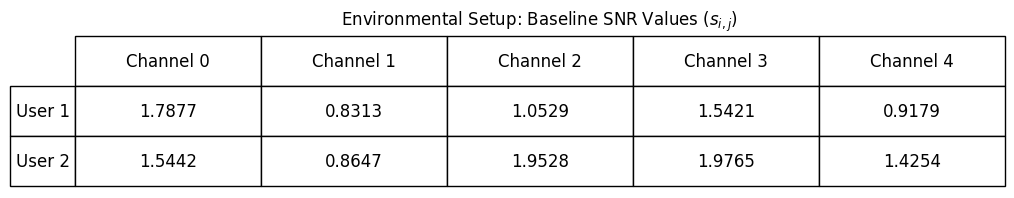

In [ ]:
K=5
epsilon=0.6
#Gemini code to show the SNR mean values in a board type
#We create a (2,K) sized matrix that stores values from 0.8 to 2.0
s_baseline= np.random.uniform(0.8,2.0,(2,K))
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')

# 2. Create the table
columns = [f"Channel {i}" for i in range(5)]
rows = ["User 1", "User 2"]
table = ax.table(cellText=np.round(s_baseline, 4),
                 colLabels=columns,
                 rowLabels=rows,
                 loc='center',
                 cellLoc='center')

# 3. Styling for a "pretty" look
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 3) # Scales row height and column width

plt.title("Environmental Setup: Baseline SNR Values ($s_{i,j}$)")
plt.show()

After we create the s_baseline we list all the possible combinations of arms (actions) our algorithm can make without any duplicates. We do so using python's built in functions:

In [ ]:
arms=list(permutations(range(K),2))
print(arms)

[(0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 3), (2, 4), (3, 0), (3, 1), (3, 2), (3, 4), (4, 0), (4, 1), (4, 2), (4, 3)]


We can now calculate the theoretical (without noise) expected rates for each played arm as well as the expected best action reward. Then we create a function where we calculate the theoretical rewards for a given arm:

In [ ]:
expected_rate = np.log(1+10*s_baseline)
expected_mij = np.array([expected_rate[0,i] + expected_rate[1,j] for i,j in arms])
expected_mbest = np.max(expected_mij)
Di = expected_mbest - expected_mij

def get_reward_theoretical(arm_ij):
  i,j=arms[arm_ij]

  s1_t = s_baseline[0,i]

  s2_t = s_baseline[1,j]

  r1 = np.log(1 + 10 * s1_t)
  r2 = np.log(1 + 10 * s2_t)

  return r1,r2

Since we have the theoretical values for our returns we should go into the simulation of the signal which **includes** noise where we must for each arm calculate the instantaneous value and calculate the rewards for a certain arm:

In [ ]:
def get_reward(arm_ij):
  i,j=arms[arm_ij]

  s1_t = np.random.uniform(s_baseline[0,i]-epsilon, s_baseline[0,i]+epsilon)

  s2_t = np.random.uniform(s_baseline[1,j]-epsilon, s_baseline[1,j]+epsilon)

  r1 = np.log(1 + 10 * s1_t)
  r2 = np.log(1 + 10 * s2_t)

  return (r1,r2)

# UCB implementation

#Case A

We now need to create our main run algorithm for each algorithm. That mode forces us to use only the aggregate value of reward and not use the individual values of it. Knowing this we can adapt the ucb algorithm to the scenario

*Task 0*
*   In this case the arm is the combination of the 2 channels
*   The learner after each round gathers the aggregate of our rewards
*  The quantity it wants to learn is the expected reward per arm





I will explain my choices here:
Since the only input our agent has is the aggregate reward of the 2 channels it must treat every combination as a different arm and an independent choice.

Now for our UCB formula, we use the formula we learned in class:

\begin{equation}
UCB_i(t) = \hat{\mu}_i(t) + \sqrt{\frac{2 \ln(t+1)}{N_i(t)}}
\end{equation}

However because reward ranges were not initialized we needed to bring the sqrt value up to the level of numbers μi has so we have to change the formula to:
\begin{equation}
UCB_i(t) = \hat{\mu}_i(t) + R_{max} \sqrt{\frac{2 \ln(t+1)}{N_i(t)}}
\end{equation}

Where:
\begin{equation}
R_{max} = 2 \cdot \log(1+10\cdot(2+ε))
\end{equation}

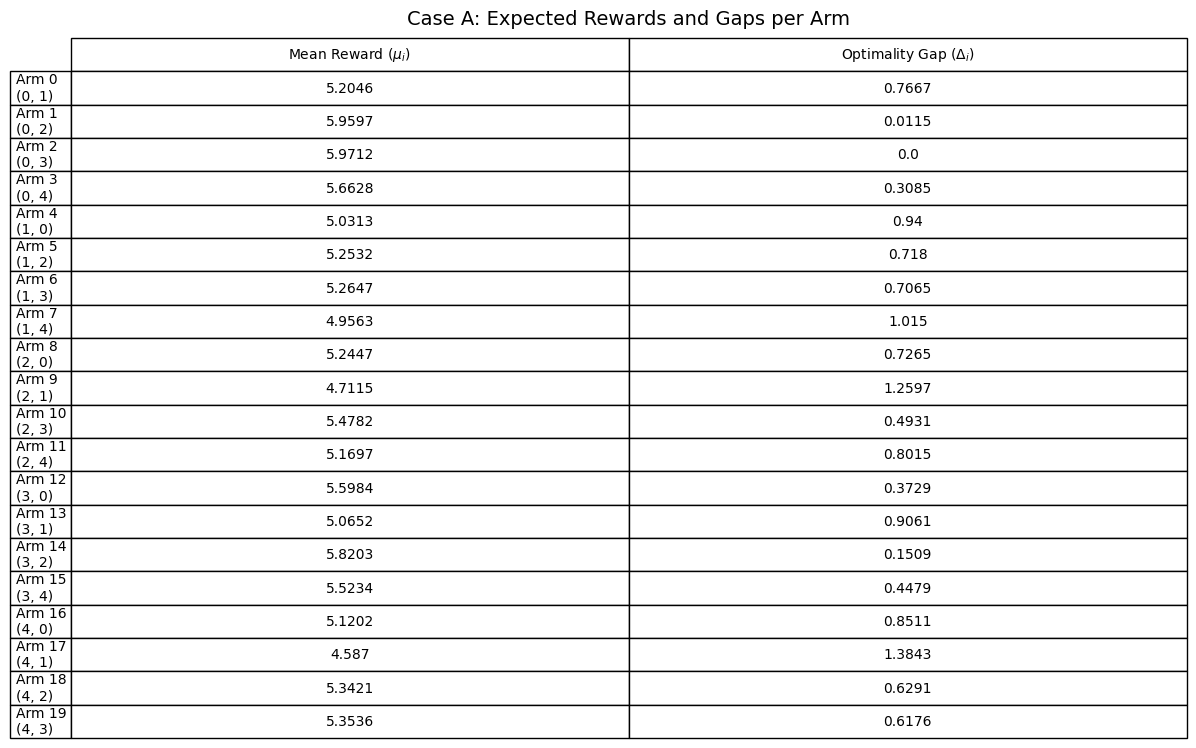

In [ ]:
#All tables for python are taken from Gemini code.
# Use raw strings (r"") for column labels to fix the SyntaxWarning
columns = [r"Mean Reward ($\mu_i$)", r"Optimality Gap ($\Delta_i$)"]

# Re-run your table creation
arm_labels = [f"Arm {i}\n{arms[i]}" for i in range(len(arms))]
table_data = np.vstack((expected_mij, Di)).T

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

table = ax.table(cellText=np.round(table_data, 4),
                 colLabels=columns,
                 rowLabels=arm_labels,
                 loc='center',
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

plt.title("Case A: Expected Rewards and Gaps per Arm", pad=40, fontsize=14)
plt.show()

*Task 1*

In [ ]:
def run_ucb_A(T):
  regret = np.zeros(T)
  t_regret = 0

  Xin = np.zeros(len(arms))
  rin = np.zeros(len(arms))
  mu_hat = np.zeros(len(arms))

  arm_i = -1

  #Because the mu_hat are much larger than the sqrt value because of the no normalization value so we need to scale the sqrt value up for it to work sublinearly
  R_max=2*np.log(1+10*(2.0+epsilon))

  for t in range(T):
    if t<len(arms):
      arm_i = t
    else:
      ucb_values = mu_hat +R_max * np.sqrt(2 * np.log(t+1) / Xin)
      arm_i = np.argmax(ucb_values)
    (r1,r2) = get_reward(arm_i)
    #What our algorithm has access to:
    reward = r1+r2
    rin[arm_i] += reward
    Xin[arm_i] += 1
    mu_hat[arm_i] =rin[arm_i] / Xin[arm_i]

    t_regret += expected_mbest - expected_mij[arm_i]
    regret[t] = t_regret

  return regret

In [ ]:
def run_ucb_A_theoretical(T):
  regret = np.zeros(T)
  t_regret = 0

  Xin = np.zeros(len(arms))
  rin = np.zeros(len(arms))
  mu_hat = np.zeros(len(arms))

  arm_i = -1

  #Because the mu_hat are much larger than the sqrt value because of the no normalization value so we need to scale the sqrt value up for it to work sublinearly
  R_max=2*np.log(1+10*(2.0+epsilon))


  for t in range(T):
    if t<len(arms):
      arm_i = t
    else:
      ucb_values = mu_hat +R_max * np.sqrt(2 * np.log(t+1) / Xin)
      arm_i = np.argmax(ucb_values)
    (r1,r2) = get_reward_theoretical(arm_i)
    #What our algorithm has access to:
    reward = r1+r2
    rin[arm_i] += reward
    Xin[arm_i] += 1
    mu_hat[arm_i] =rin[arm_i] / Xin[arm_i]

    t_regret += expected_mbest - expected_mij[arm_i]
    regret[t] = t_regret

  return regret

#Bound calculation for case A

Generally from the slides of the lesson we can follow and see the methodology for such a task since the scenario is really similar to what we've done in the classroom. More specifically the steps we are going to take to solve it are as follows:


1.   We will calculate the expected rewards of each arm. (We have already done that in the initialization so we will just use them)
2.   We will see what the best arm is and then observe the optimality gaps that are above
3.   After that I find that the smallest optimality gap is close to zero D(1) we must use an instance independent bound since the instance dependent would be too loose since:
\begin{equation}
\frac{1}{\Delta_1} \to \infty
\end{equation}
so we use the formula:
\begin{equation}
\sqrt{T\cdot\log{T}}
\end{equation}
to find the bound however the O hides the K which also needs to be used in the formula to actually get the correct result. So we add it in the formula as well as the scaling which every regret plot of mine has and thus we have our final formula:

\begin{equation}
Bound(t) = R_{max} \sqrt{K \cdot t \ln(t+1)}
\end{equation}

So by doing the calculation we find for each T that:


*   T=2000
\begin{equation}
Bound_A(2000) = 6.5917 \times \sqrt{20 \times 2000 \times \ln(2001)}
\end{equation}
\begin{equation}
Bound_A(2000) \approx 6.5917 \times \sqrt{40000 \times 7.6014} \approx 6.5917 \times 551.41 \approx \mathbf{3634.7}
\end{equation}
* T=20000
\begin{equation}
Bound_A(20000) = 6.5917 \times \sqrt{20 \times 20000 \times \ln(20001)}
\end{equation}
\begin{equation}
Bound_A(20000) \approx 6.5917 \times \sqrt{400000 \times 9.9035} \approx 6.5917 \times 1990.33 \approx \mathbf{13119.6}
\end{equation}




In [ ]:
def find_bound_a(T):
  #We use this once again because of the scaled the ucb algorithm so the bounds also need to be scaled up
  R_max=2*np.log(1+10*(2.0+epsilon))
  bound = np.zeros(T)
  for t in range(T):
  #We need to
    bound[t] =R_max*np.sqrt(len(arms)*t*np.log(t+1))
  return bound

# Case B

Case B gives us more info about the rewards since we can now gather info about the individual rewards for each user with each according channel. Knowing this we can adapt our ucb algorithm to the scenario:

*Task 0*
*   The arm in this case is the same as in case A so the arm is the combination of which signal goes to each user
*   The learner has access to the individual rates/rewards of each user with each signals.
*  My algorithm is trying to learn the expected reward per component.





I will explain my choices here:
Here I set once again the arm/ action to be the pair of the 2 channels however our agent has access to 10 different components 5 channels for each user. So our algorithm works a bit differently than case A and produces a much better result, even though the arms are the same.

Now for our UCB formula once again we use the formula we learned in class however we break it into component ucb values:
\begin{equation}
UCB_{j_1, j_2}(t) = \left( \hat{\mu}_{1,j_1} + \sqrt{\frac{2 \ln(t+1)}{N_{1,j_1}(t)}} \right) + \left( \hat{\mu}_{2,j_2} + \sqrt{\frac{2 \ln(t+1)}{N_{2,j_2}(t)}} \right)
\end{equation}
However because reward ranges were not initialized we needed to bring the sqrt value up to the level of numbers μi has so we have to change the formula to:
\begin{equation}
UCB_{j_1, j_2}(t) = \left( \hat{\mu}_{1,j_1} + R_{single} \sqrt{\frac{2 \ln(t+1)}{N_{1,j_1}(t)}} \right) + \left( \hat{\mu}_{2,j_2} + R_{single} \sqrt{\frac{2 \ln(t+1)}{N_{2,j_2}(t)}} \right)
\end{equation}
Where:
\begin{equation}
R_{single} = \log(1+10\cdot(2+ε))
\end{equation}


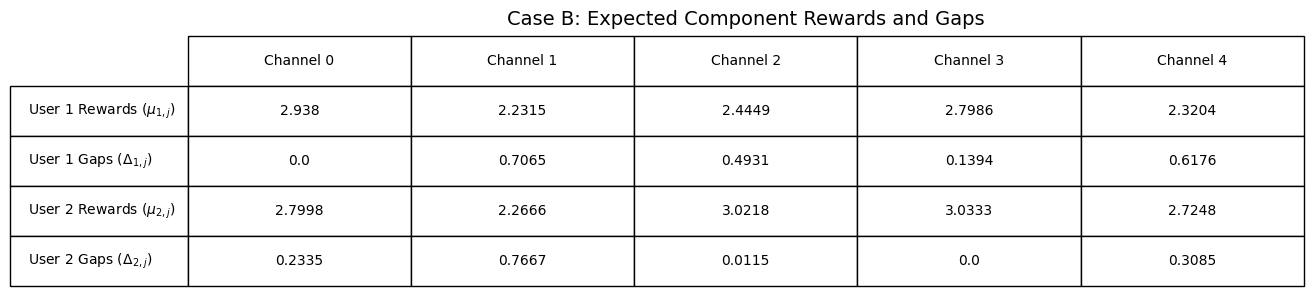

In [ ]:
r = np.zeros((2,K))
for i in range(K):
    target_pair = (i, (i + 1) % K)

    r1,r2 = get_reward_theoretical(arms.index(target_pair))
    r[0,i] += r1
    r[1,(i+1) % K] +=r2

mbest_UE1 = np.max(r[0])
mbest_UE2 = np.max(r[1])

Di_UE1 = mbest_UE1 - r[0]
Di_UE2 = mbest_UE2 - r[1]

# Prepare labels
row_labels = [r"User 1 Rewards ($\mu_{1,j}$)", r"User 1 Gaps ($\Delta_{1,j}$)",
              r"User 2 Rewards ($\mu_{2,j}$)", r"User 2 Gaps ($\Delta_{2,j}$)"]
col_labels = [f"Channel {j}" for j in range(5)]
table_data = np.vstack((r[0], Di_UE1,
                        r[1], Di_UE2))

# Setup the figure
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

# Create the table with raw strings for LaTeX headers
table = ax.table(cellText=np.round(table_data, 4),
                 colLabels=col_labels,
                 rowLabels=row_labels,
                 loc='center',
                 cellLoc='center')

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 3.0)

plt.title("Case B: Expected Component Rewards and Gaps",pad=15, fontsize=14)
plt.show()

*Task 2*

In [ ]:
def run_ucb_B(T):
  regret = np.zeros(T)
  t_regret = 0
  #2 users with 5 possible arms each so our tables are initialized as such
  Xin = np.zeros((2,K))
  rin = np.zeros((2,K))
  mu_hat = np.zeros((2,K))

  arm_i = -1

  #Because the mu_hat are much larger than the sqrt value because of the no normalization value so we need to scale the sqrt value up for it to work sublinearly
  R_max=np.log(1+10*(2.0+epsilon))

  for t in range(T):
    if t<K:
      i = t
      if t==4:
        j = 0
      else:
        j = t+1
      arm_i = arms.index((i,j))
    else:
      ucb_values = mu_hat +R_max * np.sqrt(2 * np.log(t+1) / Xin)

      reward_agg = [ucb_values[0, a[0]] + ucb_values[1, a[1]] for a in arms]
      arm_i = np.argmax(reward_agg)

    (r1,r2) = get_reward(arm_i)
    i,j = arms[arm_i]

    rin[0,i] += r1
    rin[1,j] += r2
    Xin[0,i] += 1
    Xin[1,j] += 1

    mu_hat[0,i] =rin[0,i] / Xin[0,i]
    mu_hat[1,j] =rin[1,j] / Xin[1,j]

    t_regret += expected_mbest - expected_mij[arm_i]
    regret[t] = t_regret

  return regret

In [ ]:
def run_ucb_B_theoretical(T):
  regret = np.zeros(T)
  t_regret = 0
  #2 users with 5 possible arms each so our tables are initialized as such
  Xin = np.zeros((2,K))
  rin = np.zeros((2,K))
  mu_hat = np.zeros((2,K))

  arm_i = -1

  #Because the mu_hat are much larger than the sqrt value because of the no normalization value so we need to scale the sqrt value up for it to work sublinearly
  R_max=np.log(1+10*(2.0+epsilon))

  for t in range(T):
    if t<K:
      i = t
      if t==4:
        j = 0
      else:
        j = t+1
      arm_i = arms.index((i,j))
    else:
      ucb_values = mu_hat +R_max * np.sqrt(2 * np.log(t+1) / Xin)

      reward_agg = [ucb_values[0, a[0]] + ucb_values[1, a[1]] for a in arms]
      arm_i = np.argmax(reward_agg)
    (r1,r2) = get_reward_theoretical(arm_i)
    i,j = arms[arm_i]

    rin[0,i] += r1
    rin[1,j] += r2
    Xin[0,i] += 1
    Xin[1,j] += 1

    mu_hat[0,i] =rin[0,i] / Xin[0,i]
    mu_hat[1,j] =rin[1,j] / Xin[1,j]

    t_regret += expected_mbest - expected_mij[arm_i]
    regret[t] = t_regret

  return regret

#Bound Calculation for case B

For this case we will follow a similar methodology as in case A since once again we are talking about a UCB type algorithm. However we will change some of the constants as well as how we calculate the gaps between the best arm and all the others. So let's get into it:


1.   We will calculate the expected rewards of each arm. This time with a twist we will only count the rewards of each different channel to each different user.
2.   Then we will find the maximum reward a channel can give for each user and observe the gap between them from the above table.
3. Finally after doing all that math according to the difference between the 2nd smallest gap and 0 we will decide if we are going to go for an instance dependent or an instance independent bound.

We calculated the per user gap between the best hand and every other hand in terms of value and found out that for user 2 one choice of channel has the gap really close to 0 once again we have to use instance independent bounds for them not to be as loose as the instance dependent. We calculate them with the same formula we used in case A however constants R_max and the amount of different hands has changed since we now have more information about each hand:

\begin{equation}
Bound(t) = R_{single} \sqrt{2K \cdot t \ln(t+1)}
\end{equation}
Where Max_reward is halved since we calculate reward for each hand seperately and the num of different arms is also halved since we just need to know what the reward is for each different channel for each user and not the combination of both channels

So by doing the calculation we find for each T that:


*   T=2000
\begin{equation}
Bound_B(2000) = 3.2958 \times \sqrt{10 \times 2000 \times \ln(2001)}
\end{equation}
\begin{equation}
Bound_B(2000) \approx 3.2958 \times \sqrt{20000 \times 7.6014}
\end{equation}
\begin{equation}
Bound_B(2000) \approx 3.2958 \times \sqrt{152028} \approx 3.2958 \times 389.91 \approx \mathbf{1285.1}
\end{equation}
* T=20000
\begin{equation}
Bound_B(20000) = 3.2958 \times \sqrt{10 \times 20000 \times \ln(20001)}
\end{equation}
\begin{equation}
Bound_B(20000) \approx 3.2958 \times \sqrt{200000 \times 9.9035}
\end{equation}
\begin{equation}
Bound_B(20000) \approx 3.2958 \times \sqrt{1980700} \approx 3.2958 \times 1407.37 \approx \mathbf{4638.4}
\end{equation}


In [ ]:
def find_bound_b(T):
  #We use this once again because of the scaled the ucb algorithm so the bounds also need to be scaled up
  R_max=np.log(1+10*(2.0+epsilon))

  bound = np.zeros(T)

  for t in range(T):

    bound[t] =R_max*np.sqrt(K*2*t*np.log(t+1))
  return bound

# Monte Carlo Simulation

To make the regret graphs smoother we need to use the monte carlo averaging method which runs the ucb algorithm multiple times and gets the mean value of all the regrets. This gives more value to our graphs and makes our RL algorithm be more robust. In this algorithm I change the seed for every run of it to the system time just for the noise.

In [ ]:
def monte_carlo_simulation(num, T):
  regrets_A = []
  regrets_B = []

  for i in range(num):
    np.random.seed(None)
    regret_A = run_ucb_A(T)
    regret_B = run_ucb_B(T)
    regrets_A.append(regret_A)
    regrets_B.append(regret_B)

  return np.mean(regrets_A, axis =0), np.mean(regrets_B, axis = 0)

#Initialization of our UCBs

Here we initialize and run our ucbs as many times as the num_of_mc is so we get the commulitive regret of our algorithms for times of T = 2000 and T = 20000. Also we find the bounds of each algorithm with the respective function

In [ ]:
#This is the number of monte carlo runs we want to run
num_of_mc= 20

#Grab our simulation results for each ucb algorithm for T=2000
regret_A_2K , regret_B_2K = monte_carlo_simulation(num_of_mc, 2000)
regret_A_theory_2K = run_ucb_A_theoretical(2000)
regret_B_theory_2K = run_ucb_B_theoretical(2000)
bound_A_2K = find_bound_a(2000)
bound_B_2K = find_bound_b(2000)

#Grab our simulation results for T = 20000
regret_A_20K , regret_B_20K = monte_carlo_simulation(num_of_mc, 20000)
regret_A_theory_20K = run_ucb_A_theoretical(20000)
regret_B_theory_20K = run_ucb_B_theoretical(20000)
bound_A_20K = find_bound_a(20000)
bound_B_20K = find_bound_b(20000)



# Question 1

Here we plot what is asked of us in question 1 of our description in eclass. To be more specific we are plotting next to each other the case A for both horizons with their theoretical tuned ucb so we can see how the algorithm learns over time. We also do that for case B and then print our plots in a 4x4 board.

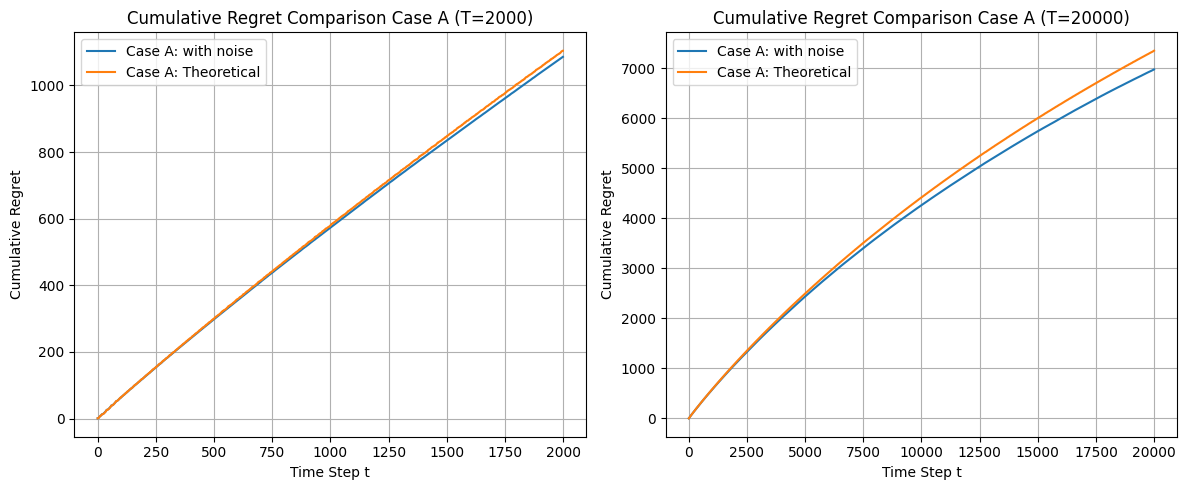

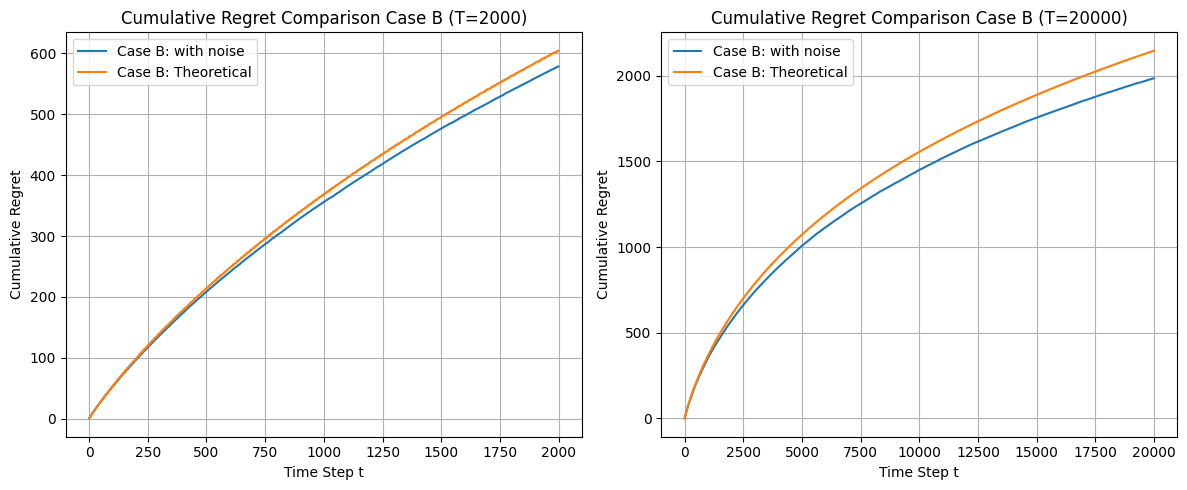

In [ ]:
#Let's start drawing our plots for question 1
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(regret_A_2K, label='Case A: with noise')
plt.plot(regret_A_theory_2K, label='Case A: Theoretical')
plt.title(f'Cumulative Regret Comparison Case A (T={2000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(regret_A_20K, label='Case A: with noise')
plt.plot(regret_A_theory_20K, label='Case A: Theoretical')
plt.title(f'Cumulative Regret Comparison Case A (T={20000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(regret_B_2K, label='Case B: with noise')
plt.plot(regret_B_theory_2K, label='Case B: Theoretical')
plt.title(f'Cumulative Regret Comparison Case B (T={2000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(regret_B_20K, label='Case B: with noise')
plt.plot(regret_B_theory_20K, label='Case B: Theoretical')
plt.title(f'Cumulative Regret Comparison Case B (T={20000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



#Question 2

In this part of the assignment I plot the bounds of each case as well as the regret for each case in their respective subplots. We can see on both plots that the regret is well below our bounds on their respective T.

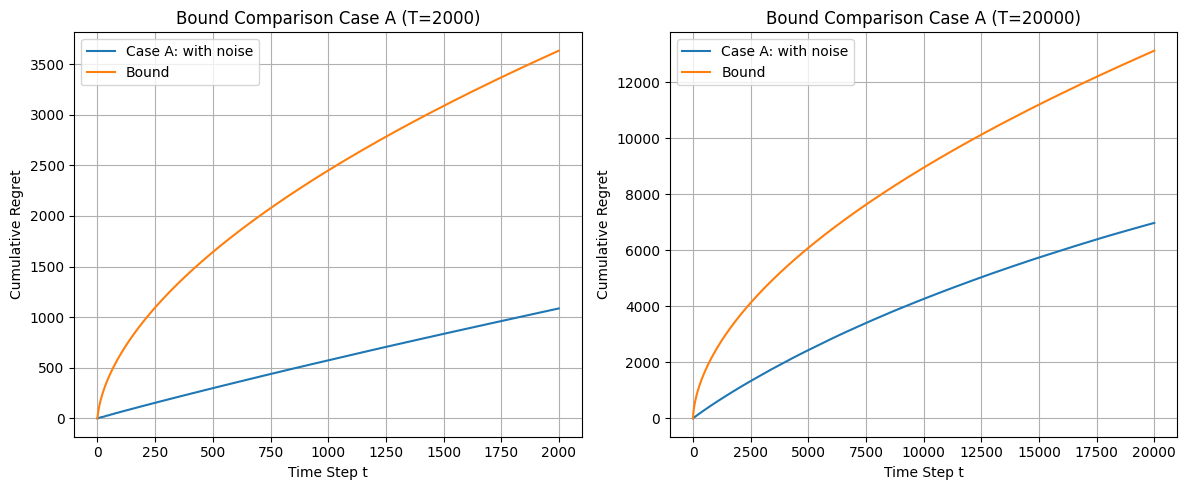

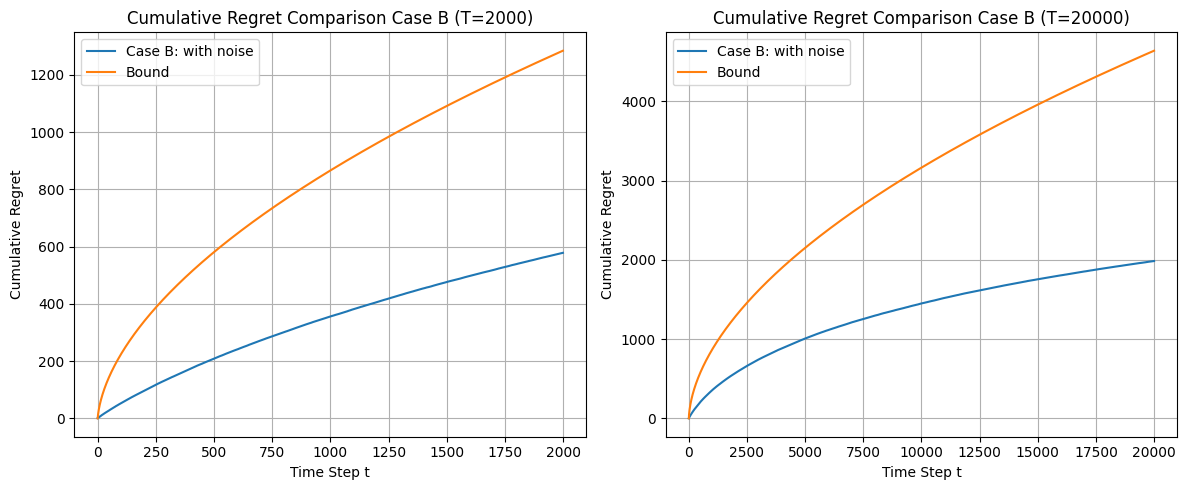

In [ ]:
#Let's start drawing our plots for question 2
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(regret_A_2K, label='Case A: with noise')
plt.plot(bound_A_2K, label='Bound')
plt.title(f'Bound Comparison Case A (T={2000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(regret_A_20K, label='Case A: with noise')
plt.plot(bound_A_20K, label='Bound')
plt.title(f'Bound Comparison Case A (T={20000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(regret_B_2K, label='Case B: with noise')
plt.plot(bound_B_2K, label='Bound')
plt.title(f'Cumulative Regret Comparison Case B (T={2000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(regret_B_20K, label='Case B: with noise')
plt.plot(bound_B_20K, label='Bound')
plt.title(f'Cumulative Regret Comparison Case B (T={20000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#Question 3

These are the most crucial plots. Here I make a comparison between case A and case B, to be more specific I compare their cumulitive regrets for both horizons. Before running the experiment I expected case B to be faster since we get more information from each T, the reward for each user and not just the aggregate, that additional information can help our agent learn a lot faster what the best subarm is for each user and then combine it into a whole arm. That is proven in the end with the plots where we see the commulitive regret being almost half in both cases. I print the cummulitive regret for both algorithms since it is what I mostly use in my algorithm and since we know it is inversly proportional with the reward. One having less regret means it has a higher total reward per played arm.

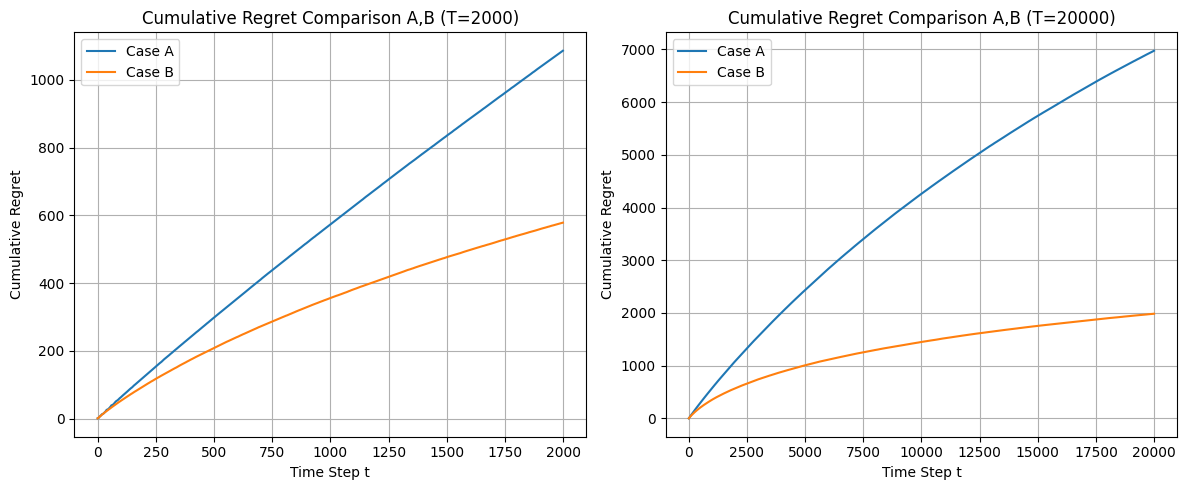

In [ ]:
#Let's start drawing our plots for question 3
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(regret_A_2K, label='Case A')
plt.plot(regret_B_2K, label='Case B')
plt.title(f'Cumulative Regret Comparison A,B (T={2000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(regret_A_20K, label='Case A')
plt.plot(regret_B_20K, label='Case B')
plt.title(f'Cumulative Regret Comparison A,B (T={20000})')
plt.xlabel('Time Step t')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

